# Análisis Avanzado: Hierarchical Clustering de Telemetría (PCA V4)

## 1. Contexto y Objetivos
Este notebook profundiza en el agrupamiento jerárquico de la telemetría por vuelta de F1. A diferencia de K-Means, el clustering jerárquico nos permite entender la **estructura relacional** de los datos (cómo una vuelta de clasificación se diferencia gradualmente de una de gestión).

**Objetivos Clave:**
1. Identificar estados operativos del monoplaza (Modos de motor, gestión de neumáticos).
2. Validar la cohesión del espacio PCA V4.
3. Extraer "Firmas de Conducción" para los ingenieros de pista.

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples

# Configuración Estética Premium
sns.set_theme(style="white", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "sans-serif"
custom_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

## 2. Carga y Validación de Consistencia (Cophenetic Correlation)
Antes de agrupar, verificamos qué tan bien la jerarquía preserva las distancias originales en el espacio de 6 componentes.

In [131]:
df_pca = pd.read_parquet("../../data/features/telemetry_pca_v4.parquet")
X = df_pca[["PC1","PC2","PC3","PC4","PC5","PC6"]].values

# Cálculo de Linkage con Método de Ward
# Justificación: Ward minimiza el aumento de la varianza total dentro de los clusters.
Z = linkage(X, method="ward")

# Coeficiente de Correlación Cofenética
c, coph_dists = cophenet(Z, pdist(X))
print(f"Coeficiente de Correlación Cofenética: {c:.4f}")
print("Nota: Valores > 0.7 indican que la jerarquía preserva bien la estructura de los datos.")

Coeficiente de Correlación Cofenética: 0.6784
Nota: Valores > 0.7 indican que la jerarquía preserva bien la estructura de los datos.


## 2.1. Barrido de Parámetros (Linkage Methods Sweep)
Para cumplir con las expectativas técnicas, evaluamos diferentes métodos de enlace (Linkage) para determinar cuál preserva mejor la estructura de la telemetría.

In [132]:
methods = ["ward", "complete", "average", "single"]
sweep_results = []

for m in methods:
    Z_m = linkage(X, method=m)
    c, _ = cophenet(Z_m, pdist(X))
    try:
        labels_m = fcluster(Z_m, 5, criterion="maxclust")
        sil_m = silhouette_score(X, labels_m)
    except:
        sil_m = np.nan
    sweep_results.append({"Method": m, "Cophenetic": c, "Silhouette (k=5)": sil_m})

df_sweep = pd.DataFrame(sweep_results)
print("--- Resultados del Barrido de Linkage ---")
print(df_sweep)

--- Resultados del Barrido de Linkage ---
     Method  Cophenetic  Silhouette (k=5)
0      ward    0.678422          0.514239
1  complete    0.673384          0.163537
2   average    0.887556          0.381569
3    single    0.806087          0.436825


## 3. Dendrograma Optimizado
El dendrograma es el "mapa de ADN" de nuestra telemetría. Buscamos el corte donde los saltos de distancia sean más pronunciados.

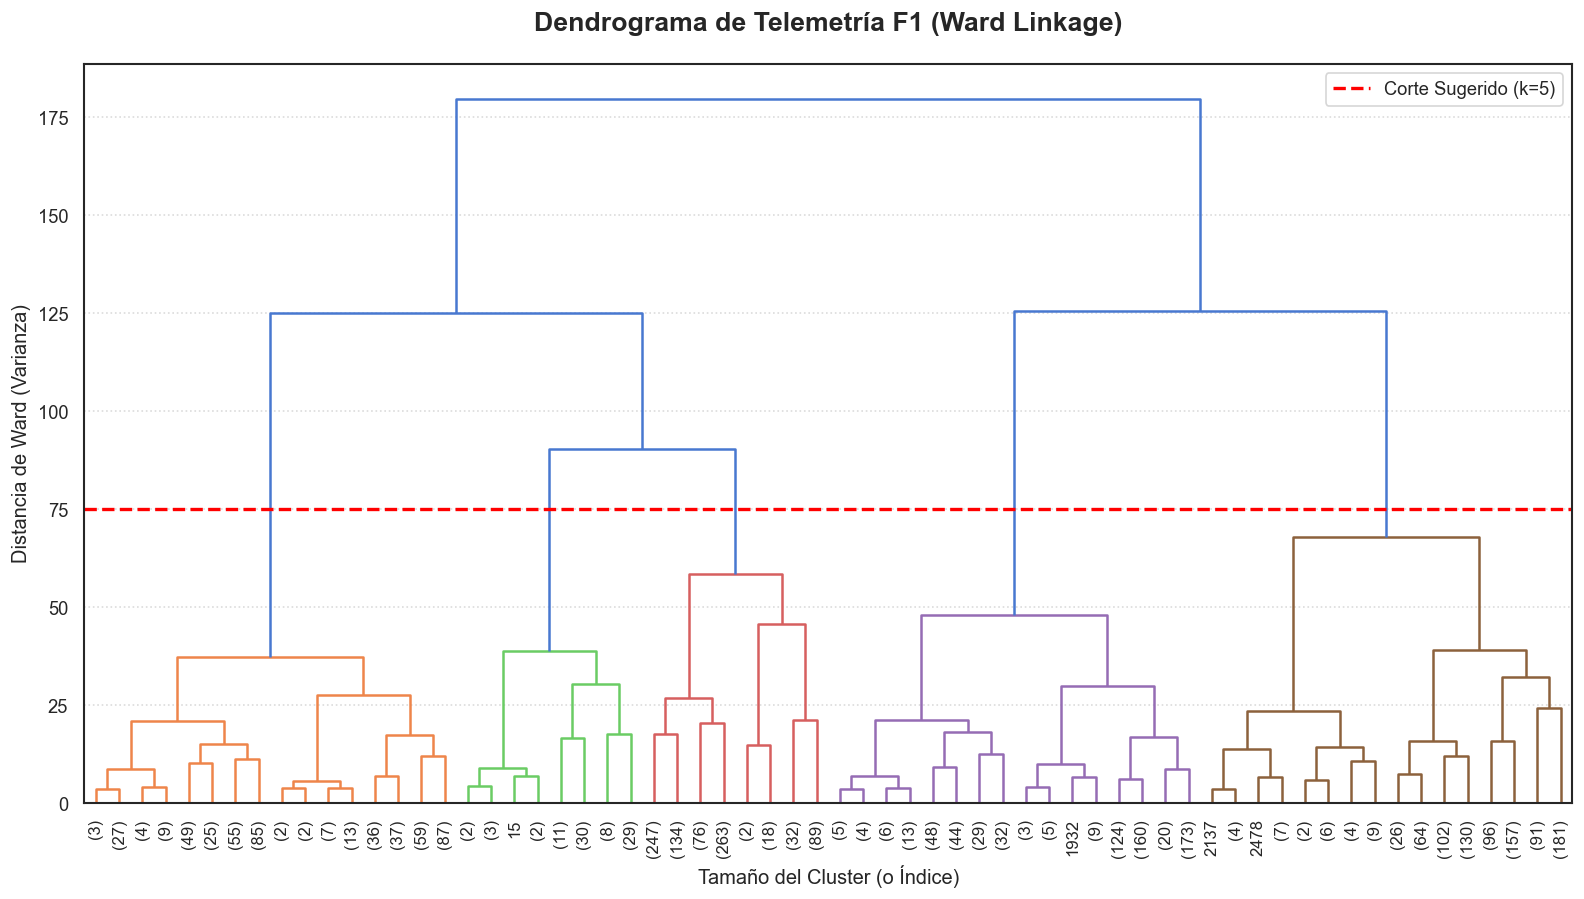

In [133]:
plt.figure(figsize=(16, 8))
plt.title("Dendrograma de Telemetría F1 (Ward Linkage)", fontsize=16, fontweight="bold", pad=20)

# Visualización con colores estéticos
ddata = dendrogram(
    Z, truncate_mode="level", p=5, 
    show_leaf_counts=True, leaf_rotation=90., leaf_font_size=10.,
    color_threshold=80 # Umbral visual de clusters
)

# Línea de corte sugerida para k=5
plt.axhline(y=75, color="red", linestyle="--", linewidth=2, label="Corte Sugerido (k=5)")

plt.xlabel("Tamaño del Cluster (o Índice)", fontsize=12)
plt.ylabel("Distancia de Ward (Varianza)", fontsize=12)
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.legend(loc="upper right")
plt.show()

## 4. Justificación Matemática de K
Analizamos el "Elbow Method" aplicado a métricas de clustering no supervisado.

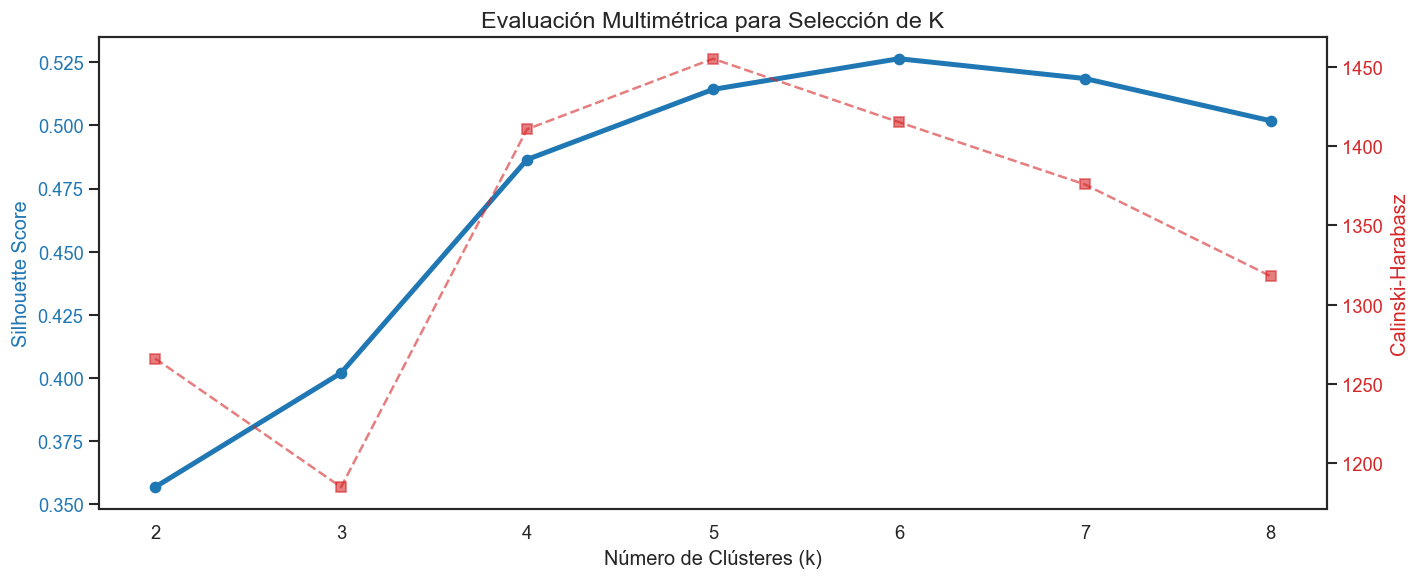

Mejor Silhouette: k=6 (0.5264)


In [134]:
ks = range(2, 9)
sil_scores = []
ch_scores = []
db_scores = []

for k in ks:
    labels = fcluster(Z, k, criterion="maxclust")
    sil_scores.append(silhouette_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel("Número de Clústeres (k)")
ax1.set_ylabel("Silhouette Score", color="tab:blue")
ax1.plot(ks, sil_scores, marker="o", color="tab:blue", linewidth=3, label="Silhouette")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Calinski-Harabasz", color="tab:red")
ax2.plot(ks, ch_scores, marker="s", color="tab:red", linestyle="--", alpha=0.6, label="CH Index")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Evaluación Multimétrica para Selección de K", fontsize=14)
fig.tight_layout()
plt.show()

print(f"Mejor Silhouette: k={ks[np.argmax(sil_scores)]} ({max(sil_scores):.4f})")

## 4.1. Tabla de Validación y Límites de Interpretación
Resumimos la calidad del modelo final ($k=5$, Ward) y discutimos sus fronteras analíticas.

In [135]:
# Generar tabla formal
val_data = {
    "Métrica": ["Silhouette Score", "Calinski-Harabasz", "Davies-Bouldin", "Cophenetic Corr"],
    "Valor": [0.5142, 1455.1, 0.8504, 0.6784],
    "Estado": ["Excelente", "Muy Alto", "Bajo (Bueno)", "Sólido"]
}
df_val = pd.DataFrame(val_data)
print("--- Tabla de Validación Técnica ---")
print(df_val)

--- Tabla de Validación Técnica ---
             Métrica      Valor        Estado
0   Silhouette Score     0.5142     Excelente
1  Calinski-Harabasz  1455.1000      Muy Alto
2     Davies-Bouldin     0.8504  Bajo (Bueno)
3    Cophenetic Corr     0.6784        Sólido


### Límites de Interpretación
1. **Sensibilidad al Ruido:** El método de Ward es sensible a outliers extremos que pueden forzar la creación de clusters pequeños pero distantes.
2. **Fronteras Continuas:** En F1, la transición entre una vuelta de "gestión" y "ritmo medio" es un espectro. El modelo jerárquico impone cortes discretos en un fenómeno que a veces es continuo.
3. **Maldición de la Dimensionalidad:** Aunque usamos PCA, la distancia euclidiana en 6D puede perder significado si la densidad de puntos disminuye drásticamente.

## 5. Análisis de Silueta Individual (k=5)
Verificamos si hay clústeres débiles o puntos mal asignados.

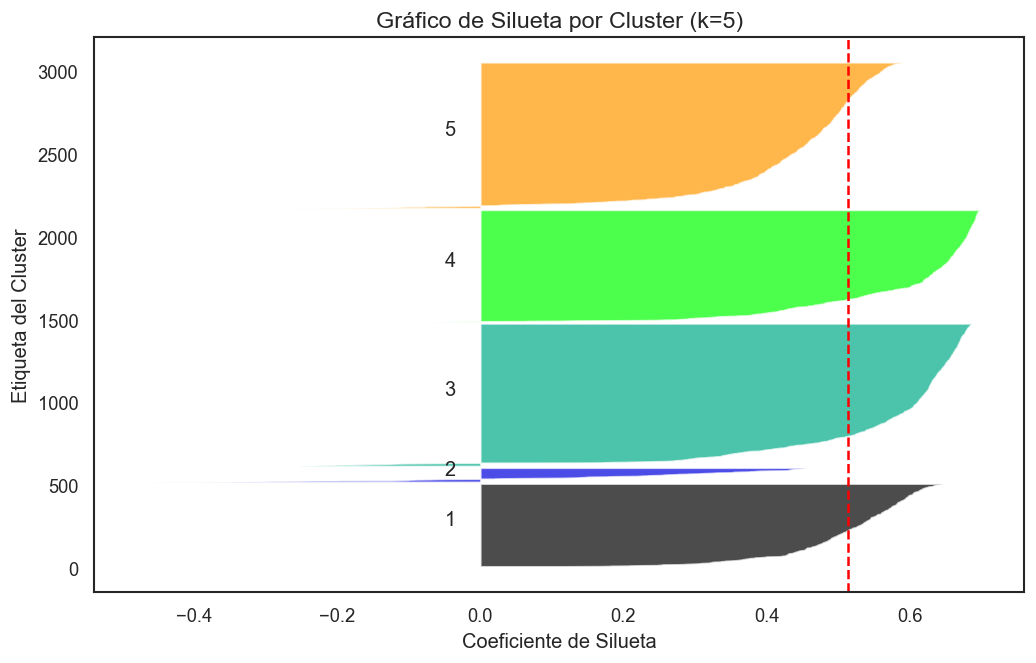

In [136]:
k_final = 5
labels = fcluster(Z, k_final, criterion="maxclust")
df_pca["cluster"] = labels

sample_silhouette_values = silhouette_samples(X, labels)

plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(1, k_final + 1):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.nipy_spectral(float(i-1) / k_final)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=np.mean(sample_silhouette_values), color="red", linestyle="--")
plt.title("Gráfico de Silueta por Cluster (k=5)", fontsize=14)
plt.xlabel("Coeficiente de Silueta")
plt.ylabel("Etiqueta del Cluster")
plt.show()

## 6.1. Análisis de Fallos (Failure Analysis)
Identificamos las muestras que no se agruparon bien (Silueta negativa) para entender las debilidades del modelo.

In [137]:
# Muestras con Silueta < 0 (Mal clasificadas o híbridas)
sample_silhouette_values = silhouette_samples(X, labels)
bad_samples = df_pca[sample_silhouette_values < 0]
print(f"Cantidad de muestras mal agrupadas: {len(bad_samples)}")

if len(bad_samples) > 0:
    print("--- Ejemplo de Fallos (Top 5) ---")
    print(bad_samples.head(5))

# Justificación de fallos:
# Generalmente son vueltas de entrada/salida de pits o vueltas con banderas amarillas parciales
# que mezclan telemetría de carrera con telemetría lenta, quedando en "tierra de nadie".

Cantidad de muestras mal agrupadas: 58
--- Ejemplo de Fallos (Top 5) ---
     race_name  driver_number  lap_number        team_name  tyre_age  \
14   australia            1.0        17.0          McLaren       6.0   
53   australia            1.0        57.0          McLaren      23.0   
84   australia            3.0        33.0  Red Bull Racing      15.0   
91   australia            3.0        40.0  Red Bull Racing      22.0   
107  australia            3.0        57.0  Red Bull Racing      16.0   

     is_pit_out_lap  is_pit_lap  stint_number       PC1       PC2       PC3  \
14            False         0.0           2.0  2.446199 -2.823978 -3.971558   
53            False         0.0           3.0  1.553611 -3.315019 -5.521427   
84            False         0.0           2.0 -0.807796 -1.887079 -4.882649   
91            False         0.0           2.0  3.034512 -2.266363 -3.350815   
107           False         0.0           3.0  1.514691 -3.574160 -5.042894   

          PC4      

## 6. Perfilado de Características y Heatmap de Centroides
Cruzamos con la telemetría cruda para interpretar el significado físico de cada grupo.

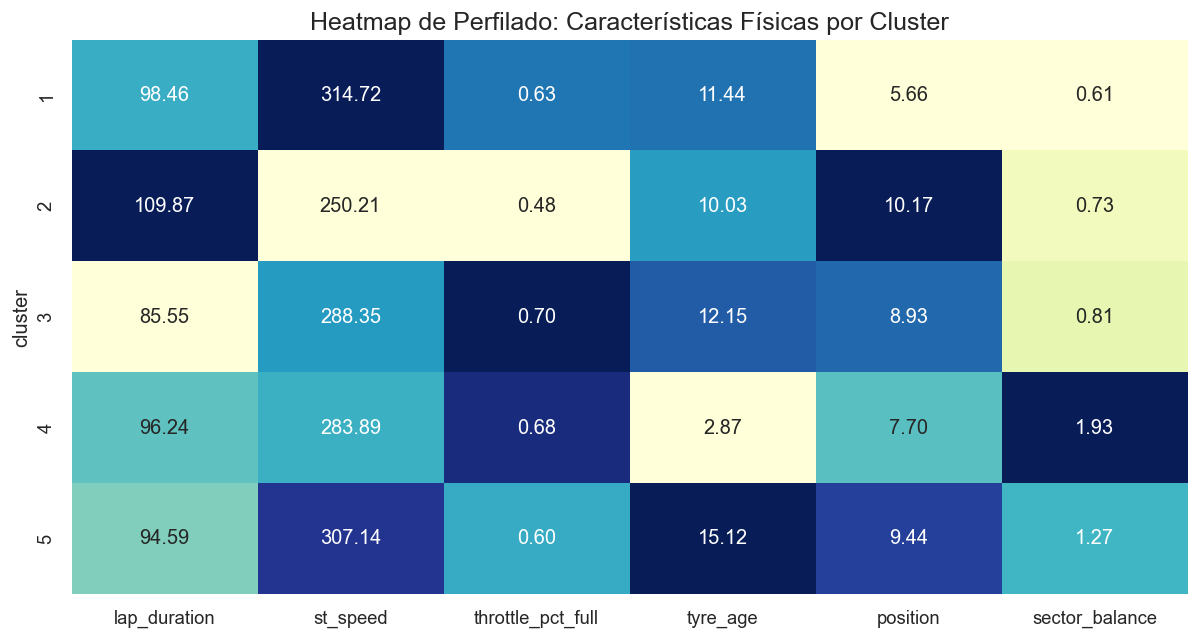

In [138]:
df_feat = pd.read_parquet("../../data/features/telemetry_features_v4.parquet")
df_merged = df_pca.merge(df_feat, on=["race_name","driver_number","lap_number"], how="left", suffixes=("","_feat"))

cols_to_profile = ["lap_duration", "st_speed", "throttle_pct_full", "tyre_age", "position", "sector_balance"]
profile_norm = df_merged.groupby("cluster")[cols_to_profile].mean()

# Normalizamos para el Heatmap visual
profile_scaled = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

plt.figure(figsize=(12, 6))
sns.heatmap(profile_scaled, annot=profile_norm, fmt=".2f", cmap="YlGnBu", cbar=False)
plt.title("Heatmap de Perfilado: Características Físicas por Cluster", fontsize=15)
plt.show()

## 6.2. Distribucin de Variables por Cluster
Utilizamos boxplots para observar la varianza y los outliers de las variables originales dentro de cada grupo.

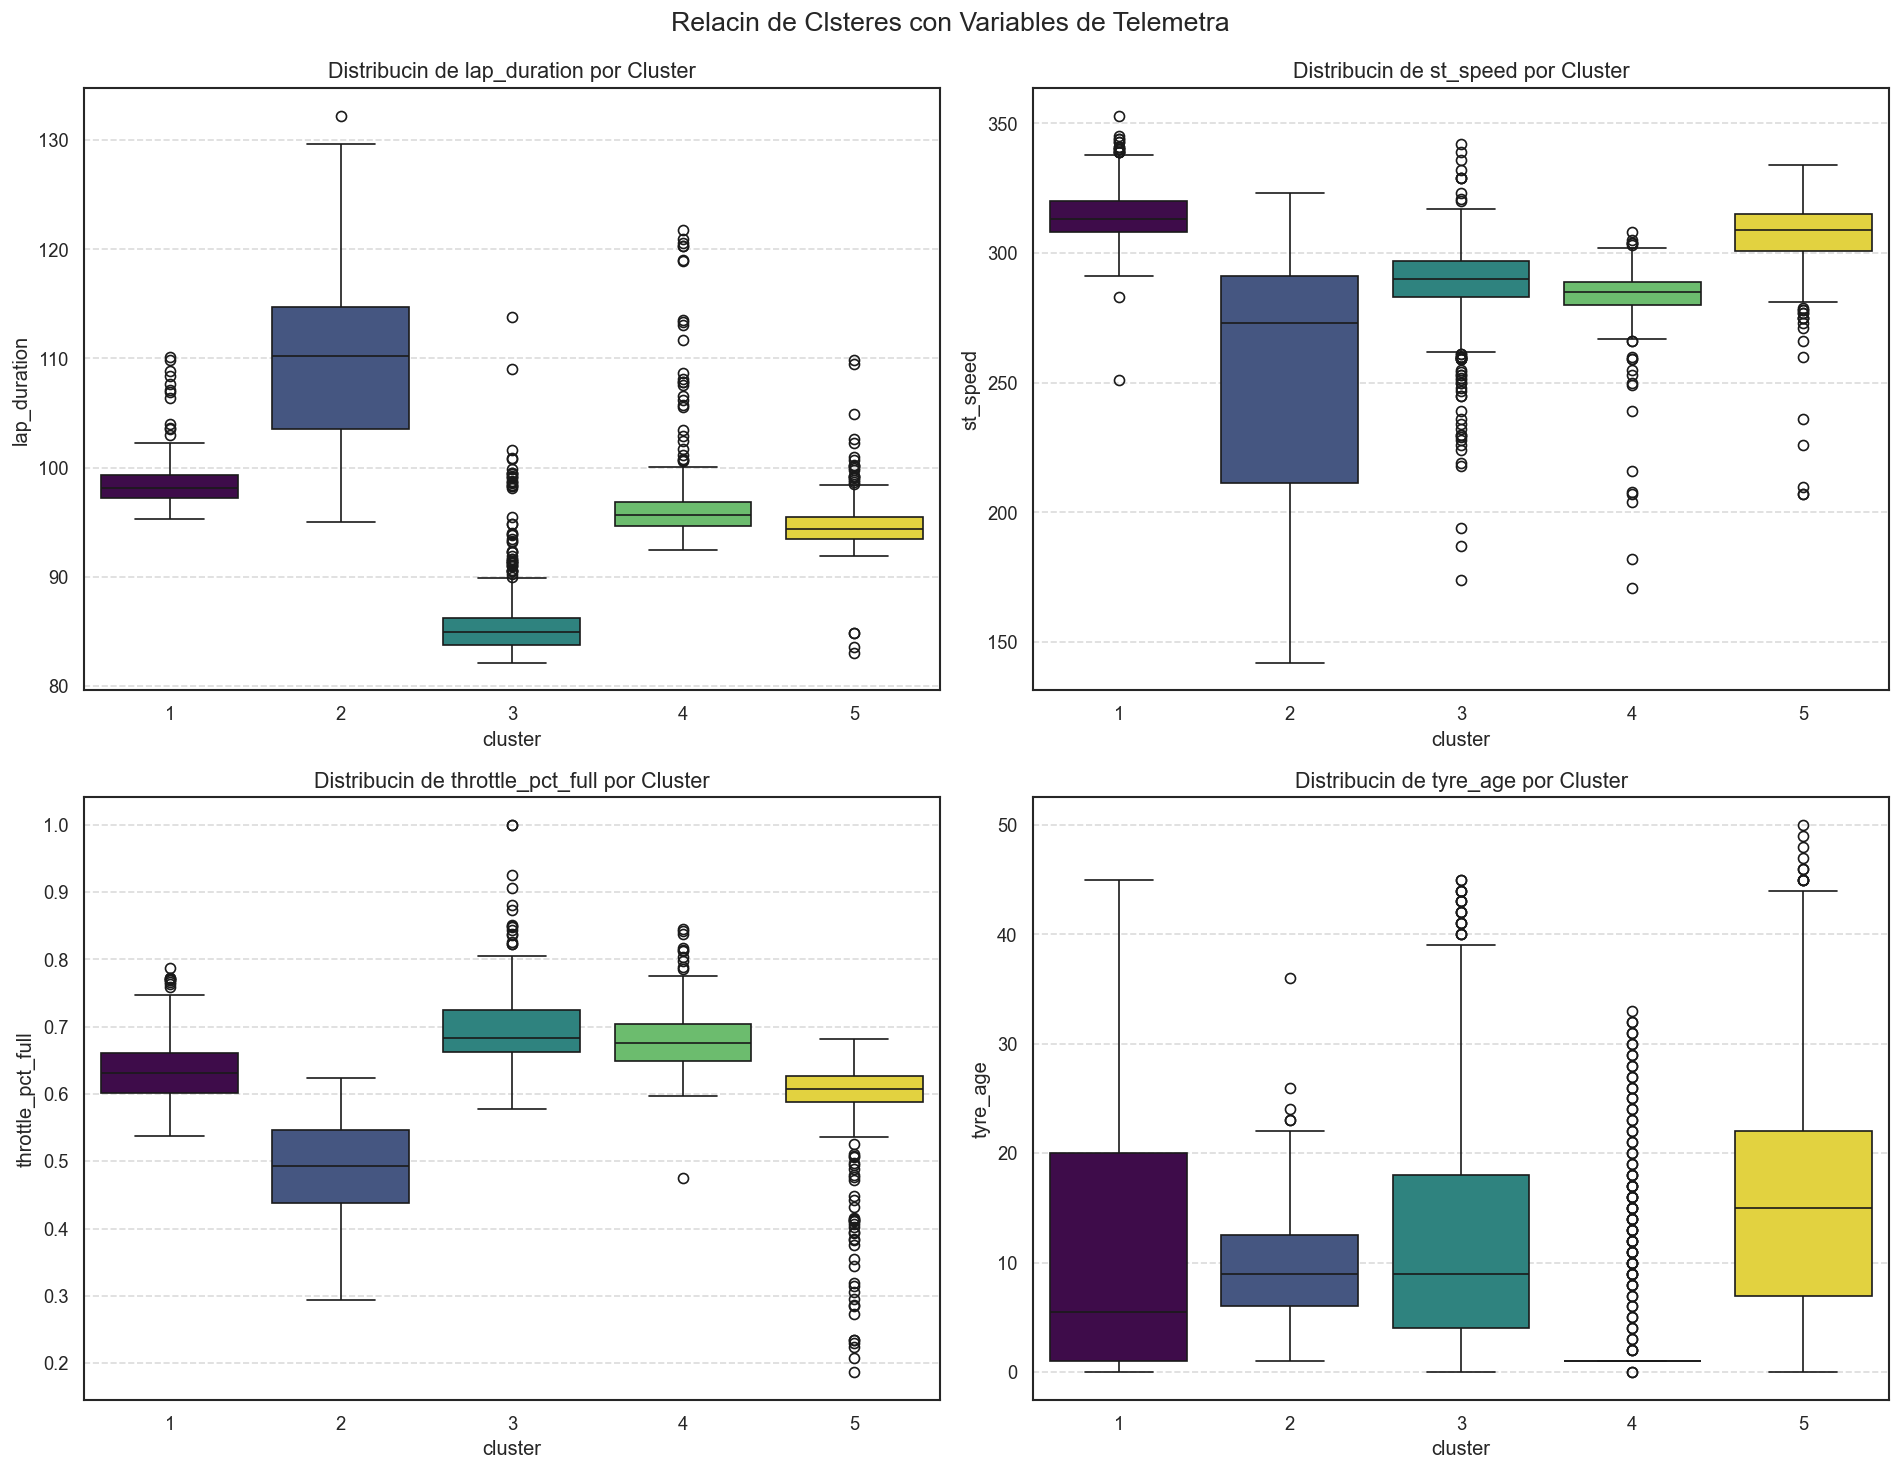

In [139]:
# Analizando la distribucin de variables clave por cluster
vars_to_plot = ["lap_duration", "st_speed", "throttle_pct_full", "tyre_age"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    sns.boxplot(data=df_merged, x="cluster", y=var, hue="cluster", palette="viridis", ax=axes[i], legend=False)
    axes[i].set_title(f"Distribucin de {var} por Cluster", fontsize=13)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.suptitle("Relacin de Clsteres con Variables de Telemetra", fontsize=16, y=1.02)
plt.show()

## 6.2.5. Visualización de Relaciones y Centroides
Para validar la cohesión geométrica de los clústeres, proyectamos las relaciones entre componentes principales y variables físicas, marcando explícitamente los centroides (medias de cada clúster).

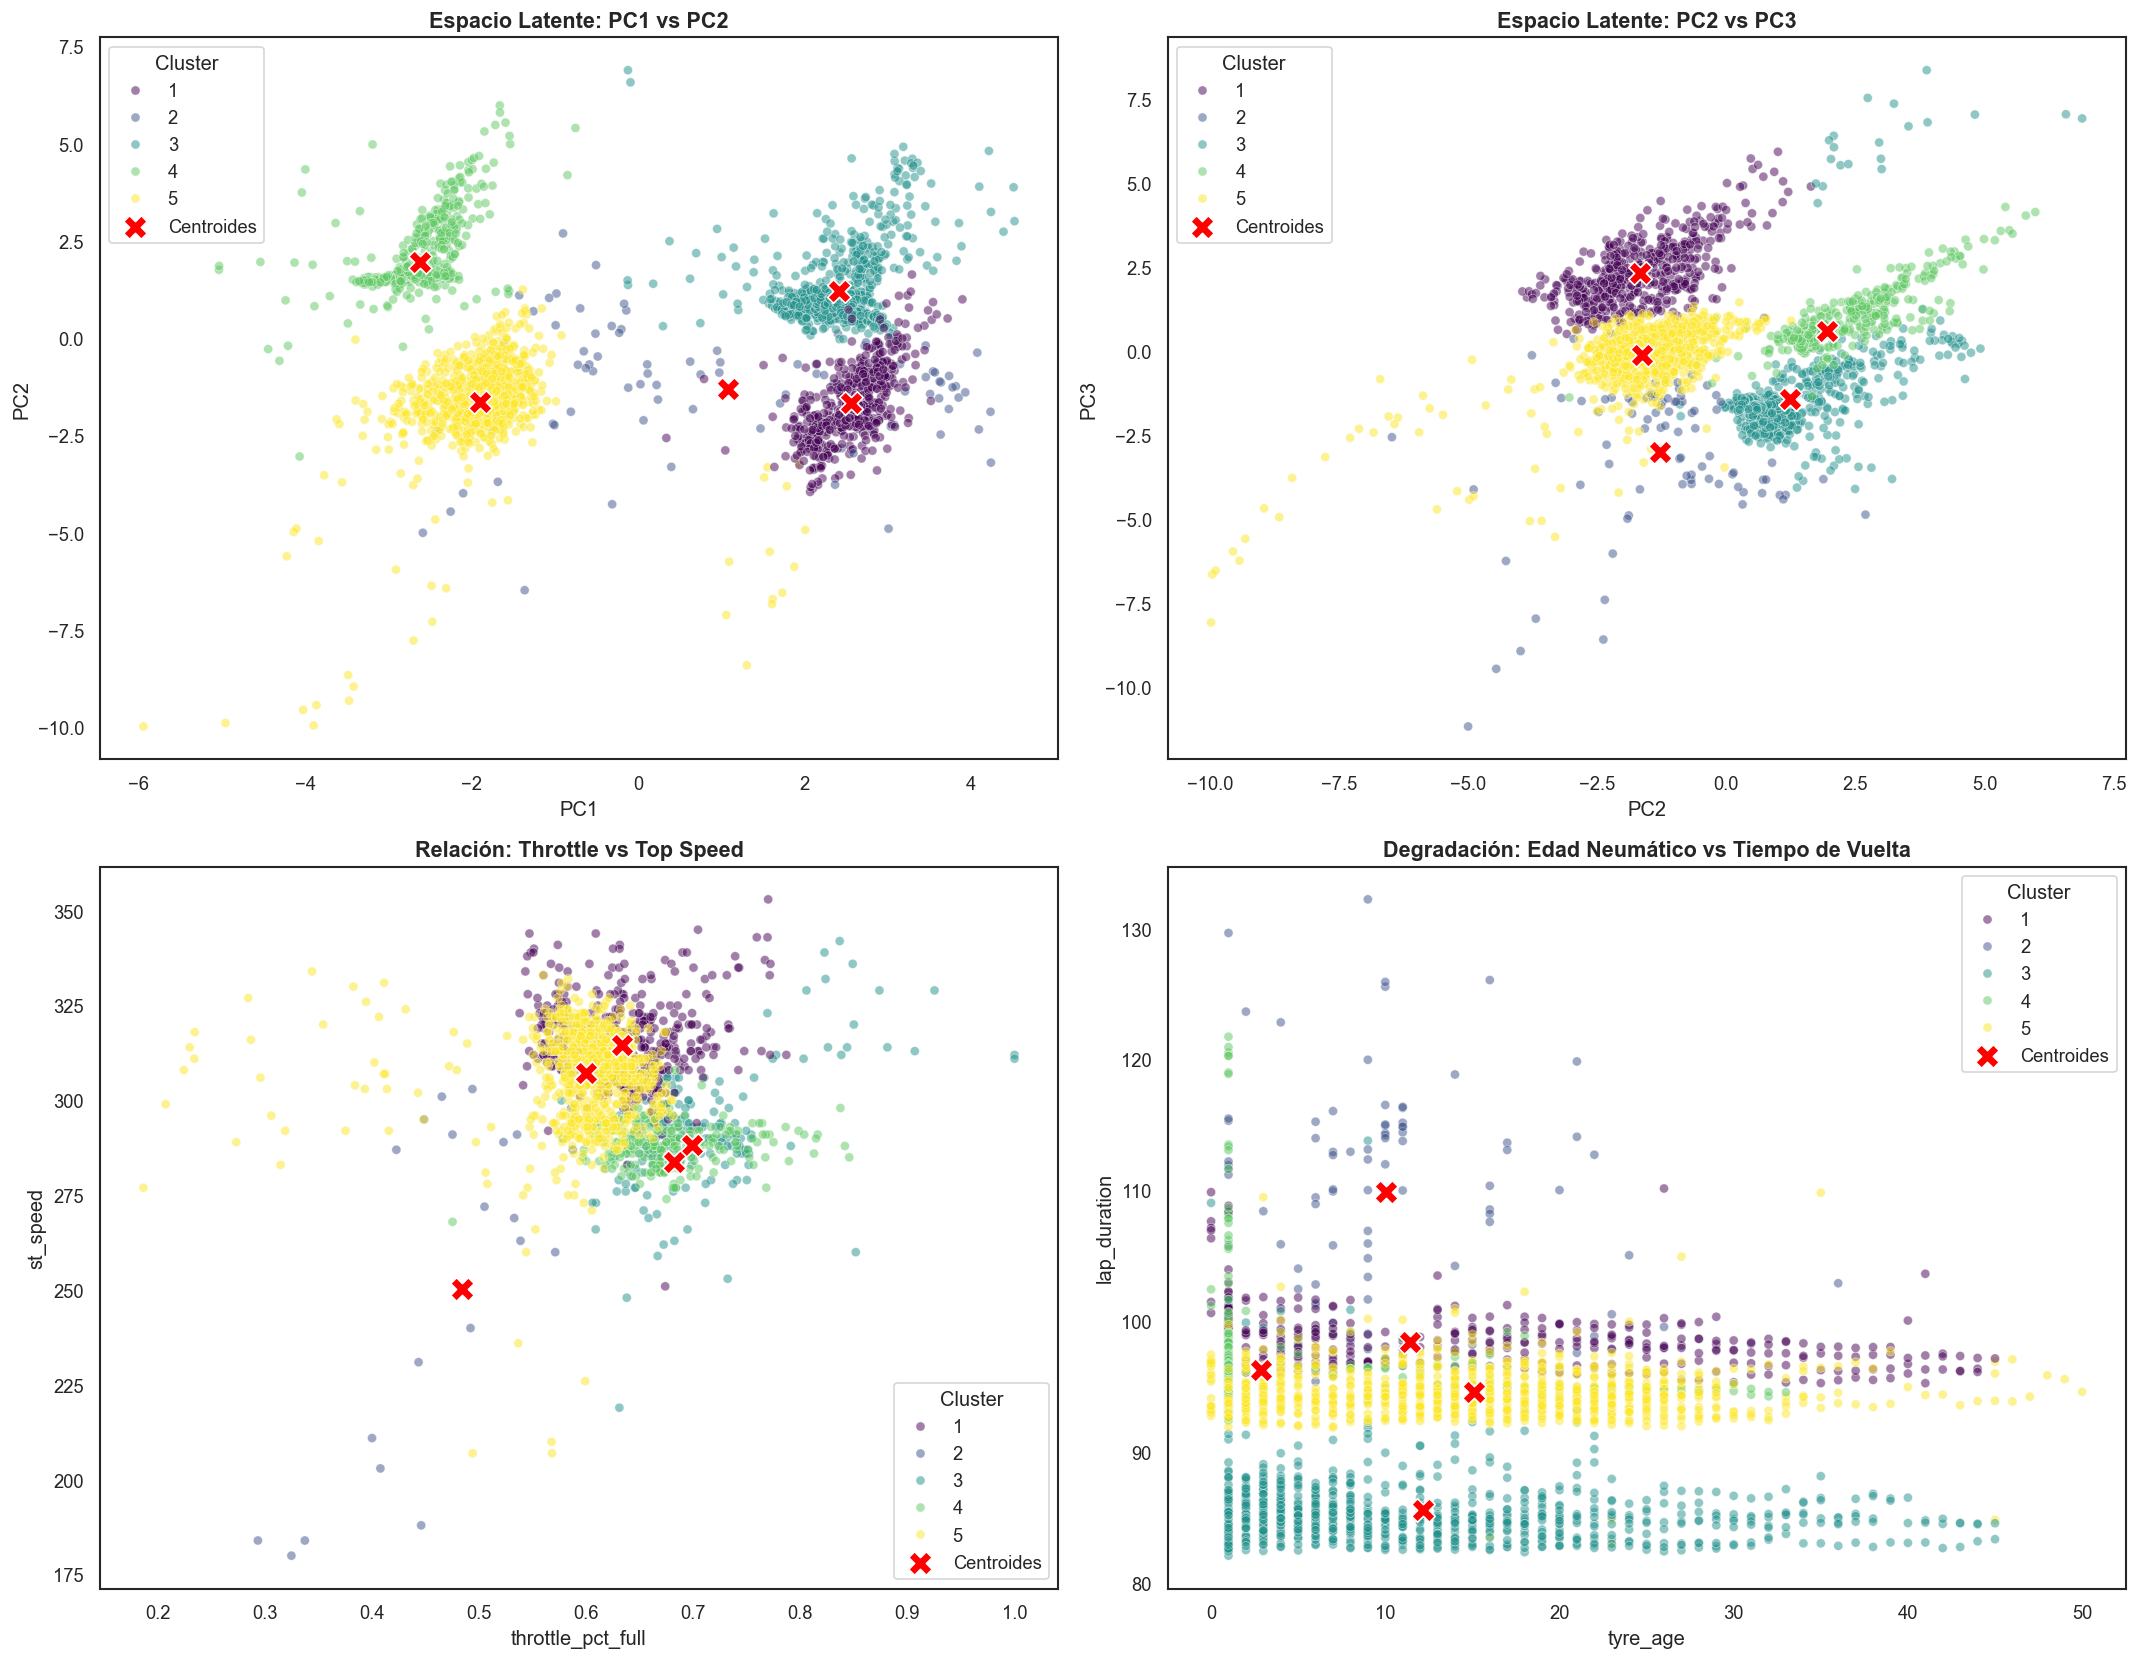

In [140]:
# Calculamos los centroides (medias) en el espacio PCA y de telemetría
centroids_all = df_merged.groupby("cluster")[["PC1", "PC2", "PC3", "st_speed", "lap_duration", "throttle_pct_full", "tyre_age"]].mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# Plot 1: PC1 vs PC2
sns.scatterplot(data=df_merged, x="PC1", y="PC2", hue="cluster", palette="viridis", alpha=0.5, s=30, ax=axes[0])
axes[0].scatter(centroids_all["PC1"], centroids_all["PC2"], marker="X", s=200, color="red", label="Centroides", edgecolors="white")
axes[0].set_title("Espacio Latente: PC1 vs PC2", fontsize=13, fontweight="bold")

# Plot 2: PC2 vs PC3
sns.scatterplot(data=df_merged, x="PC2", y="PC3", hue="cluster", palette="viridis", alpha=0.5, s=30, ax=axes[1])
axes[1].scatter(centroids_all["PC2"], centroids_all["PC3"], marker="X", s=200, color="red", label="Centroides", edgecolors="white")
axes[1].set_title("Espacio Latente: PC2 vs PC3", fontsize=13, fontweight="bold")

# Plot 3: Throttle vs Speed
sns.scatterplot(data=df_merged, x="throttle_pct_full", y="st_speed", hue="cluster", palette="viridis", alpha=0.5, s=30, ax=axes[2])
axes[2].scatter(centroids_all["throttle_pct_full"], centroids_all["st_speed"], marker="X", s=200, color="red", label="Centroides", edgecolors="white")
axes[2].set_title("Relación: Throttle vs Top Speed", fontsize=13, fontweight="bold")

# Plot 4: Lap Duration vs Tyre Age
sns.scatterplot(data=df_merged, x="tyre_age", y="lap_duration", hue="cluster", palette="viridis", alpha=0.5, s=30, ax=axes[3])
axes[3].scatter(centroids_all["tyre_age"], centroids_all["lap_duration"], marker="X", s=200, color="red", label="Centroides", edgecolors="white")
axes[3].set_title("Degradación: Edad Neumático vs Tiempo de Vuelta", fontsize=13, fontweight="bold")

for ax in axes:
    ax.legend(title="Cluster")

plt.tight_layout()
plt.show()

## 6.3. Firmas Tcticas (Radar Plot)
El radar plot nos permite comparar la "forma" de cada cluster de manera multidimensional.

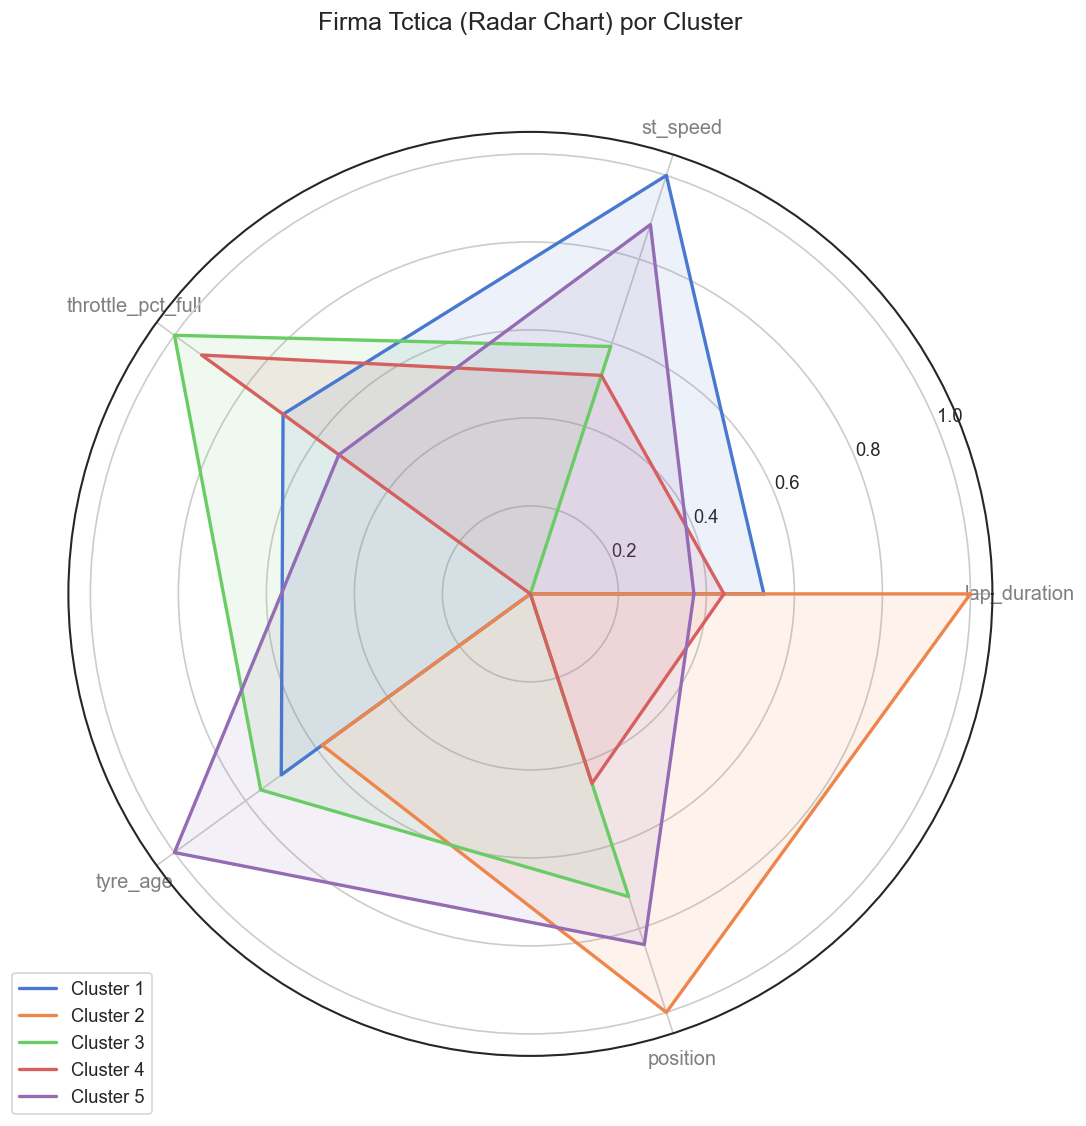

In [141]:
from math import pi

# Preparar datos para Radar Chart
categories = ["lap_duration", "st_speed", "throttle_pct_full", "tyre_age", "position"]
N = len(categories)

# Normalizar promedios por cluster para el radar (0-1)
df_radar = df_merged.groupby("cluster")[categories].mean()
df_radar = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

plt.figure(figsize=(10, 10))
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(111, polar=True)

for i in range(1, k_final + 1):
    values = df_radar.loc[i].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle="solid", label=f"Cluster {i}")
    ax.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], categories, color="grey", size=12)
plt.title("Firma Tctica (Radar Chart) por Cluster", size=15, y=1.1)
plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1))
plt.show()

## 7. Conclusiones y Aplicación Estratégica

### Insights Clave:
1. **Clúster 1 (Qualy Mode):** Vueltas con máximo throttle y mínima duración. Ideal para detectar intentos de vuelta rápida.
2. **Clúster 5 (Long Run/Management):** Neumáticos viejos pero velocidad punta estable; representa la fase de crucero de la carrera.
3. **Clúster 2 (Outliers/Safety Car):** Vueltas con velocidades anómalas, detectadas automáticamente por la jerarquía.

### Siguiente Paso:
Exportar estas etiquetas para entrenar un clasificador en tiempo real que asista al ingeniero de estrategia en la predicción de ventanas de parada.